In [35]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [41]:
class Operation(TypedDict):
    user_input: int
    positive: str 
    negative: str
    even: str
    odd: str
    final_result: str

In [42]:
def isPositive(state: Operation) -> Operation:
    return {"positive": "The given number is positive"}
    
    
def isNegative(state: Operation) -> Operation:
    # partial update of the state 
    return {"negative": "The given number is negative"}
    

# need to add node_name here as a return tyoe
def checkConditions(state: Operation) -> Literal["check_positive", "check_negative"]:
    if state["user_input"] >= 0:
        return "check_positive"
    return "check_negative"

In [46]:
def isEven(state: Operation):
    return {"even": "Even number", "final_result": "The give number is positive and it is Even"}

def isOdd(state: Operation):
    return {"even": "Odd number", "final_result": "The give number is positive and it is Odd"}


def checkConditions2(state: Operation) -> Literal["check_odd", "check_even"]:
    if state["user_input"] % 2 == 0:
        return "check_even"
    else:
        return "check_odd"


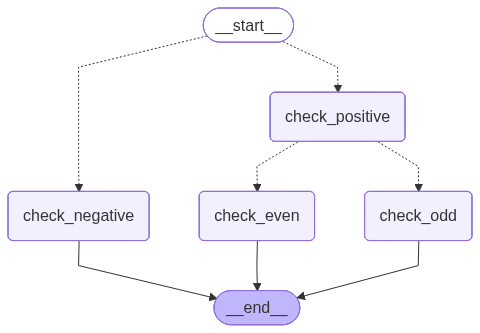

In [47]:
graph = StateGraph(Operation)

# node name and function
graph.add_node("check_positive", isPositive)
graph.add_node("check_negative", isNegative)
graph.add_node("check_even", isEven)
graph.add_node("check_odd", isOdd)

# we need to add conditional edges from which node to start
graph.add_conditional_edges(START, checkConditions)
graph.add_edge("check_negative", END)

# nodes used inside conditional branching needs to be added
graph.add_conditional_edges("check_positive", checkConditions2)

graph.add_edge("check_even", END)
graph.add_edge("check_odd", END)

workflow = graph.compile()
workflow

In [48]:
workflow.invoke({"user_input": 15})

{'user_input': 15,
 'positive': 'The given number is positive',
 'even': 'Odd number',
 'final_result': 'The give number is positive and it is Odd'}

In [49]:
workflow.invoke({"user_input": 22})

{'user_input': 22,
 'positive': 'The given number is positive',
 'even': 'Even number',
 'final_result': 'The give number is positive and it is Even'}

In [50]:
workflow.invoke({"user_input": -15})

{'user_input': -15, 'negative': 'The given number is negative'}